In [4]:
import uproot
import numpy as np
import matplotlib.pyplot as plt


In [5]:

# Open the ROOT file
file = uproot.open("/home/daq/Desktop/prove_digitizer/prova_VME_32ch_CERN_.root")
tree = file["wfm"]


In [ ]:
# Time axis: 1024 samples, 200 ps per bin (5 GS/s)
dt = 200e-12  # 200 ps = 200e-12 s
n_samples = 1024
time = np.arange(n_samples) * dt * 1e9  # convert to ns for readability

# List of waveform channels and triggers
wave_channels = [f"w{i}" for i in range(32)]
trg_channels = [f"trg{i}" for i in range(4)]

# Pick first 10 events
n_events = 10

# Plot waveforms
for ch in wave_channels + trg_channels:
    # Load channel data (uproot gives jagged arrays for vectors)
    data = tree[ch].array(library="np")

    plt.figure(figsize=(10, 6))
    for evt in range(n_events):
        plt.plot(time, data[evt], label=f"Event {evt}")

    plt.title(f"Channel {ch} - First {n_events} Waveforms")
    plt.xlabel("Time [ns]")
    plt.ylabel("Amplitude [a.u.]")
    plt.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()


Plotting the RMS to make sure the (which) channels are connected

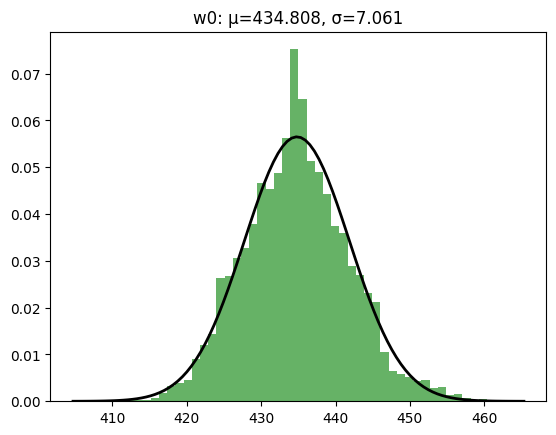

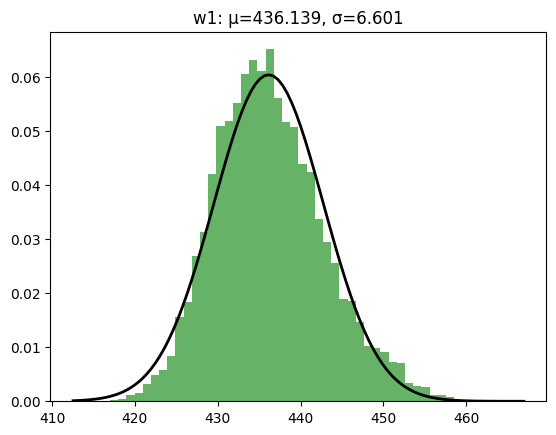

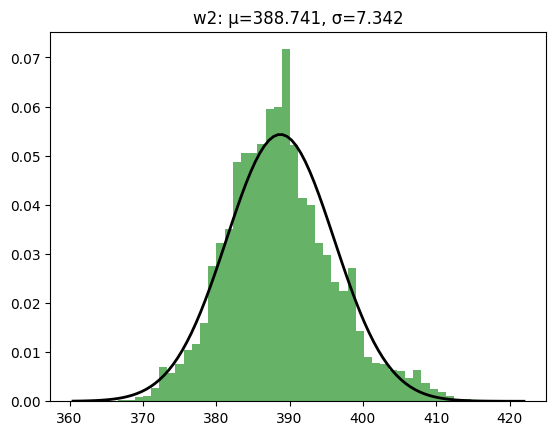

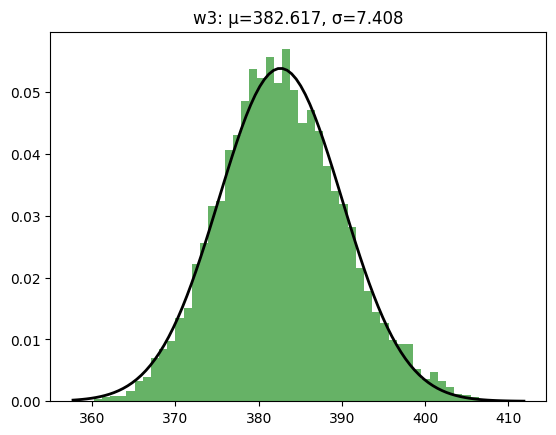

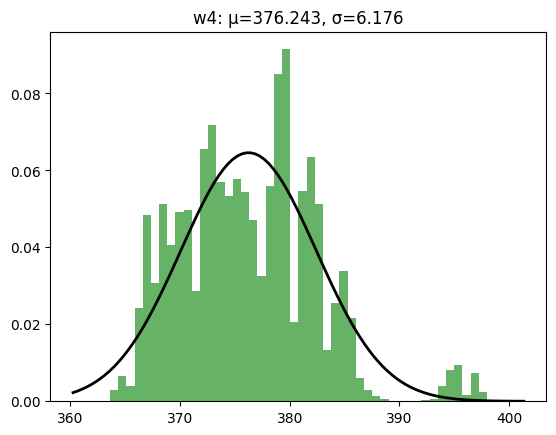

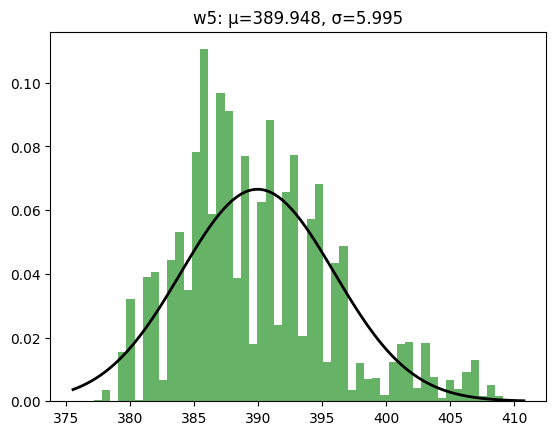

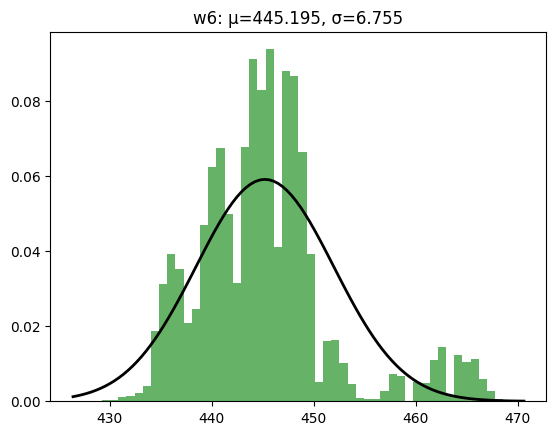

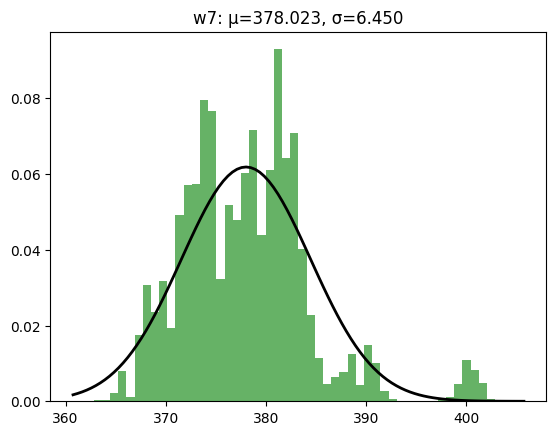

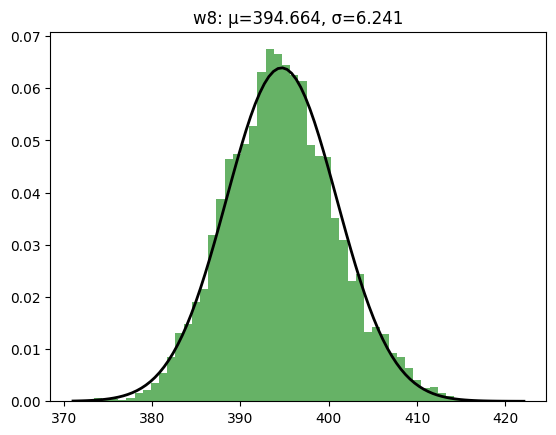

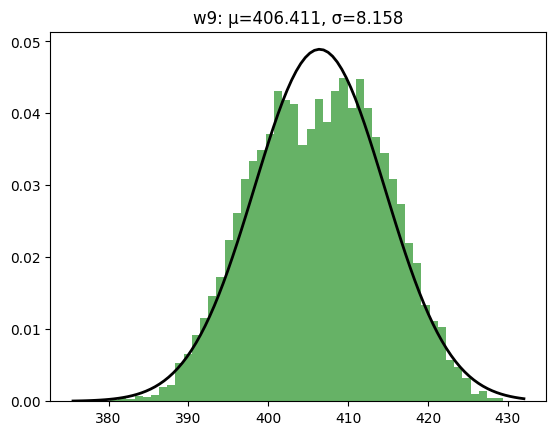

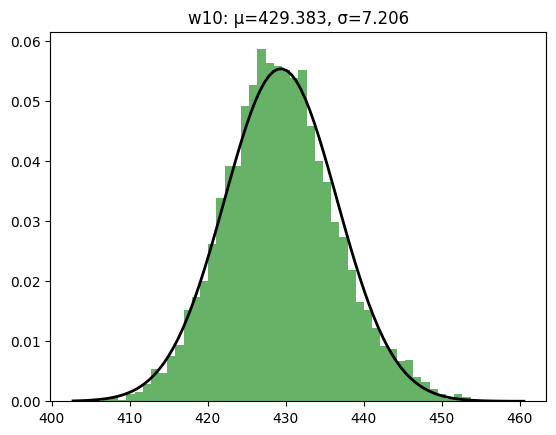

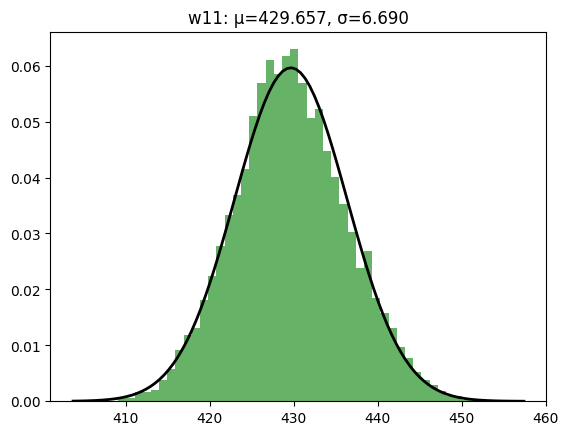

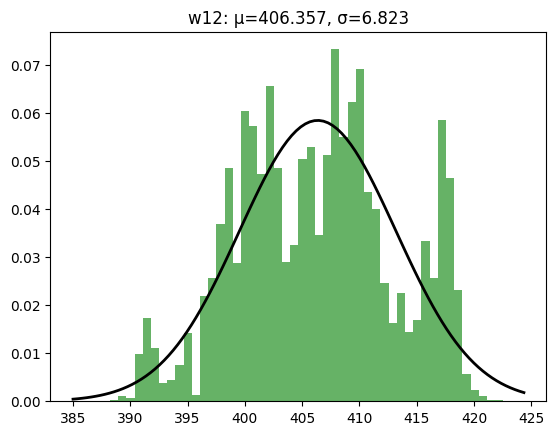

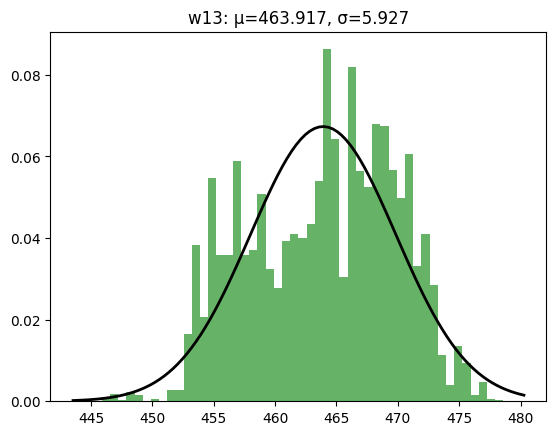

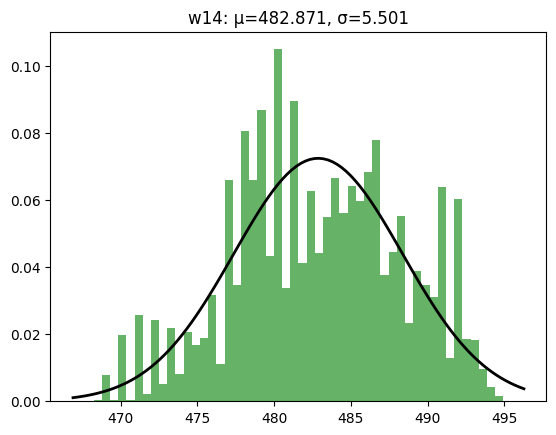

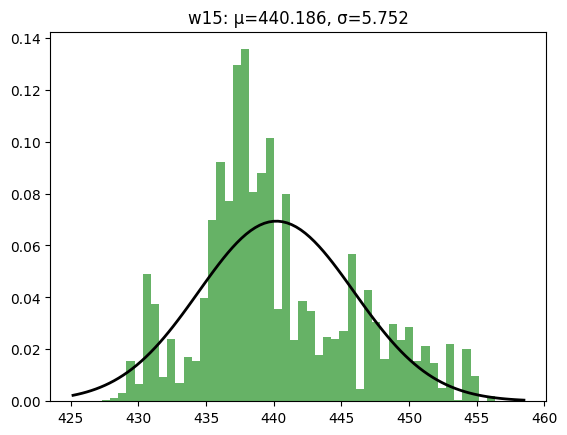

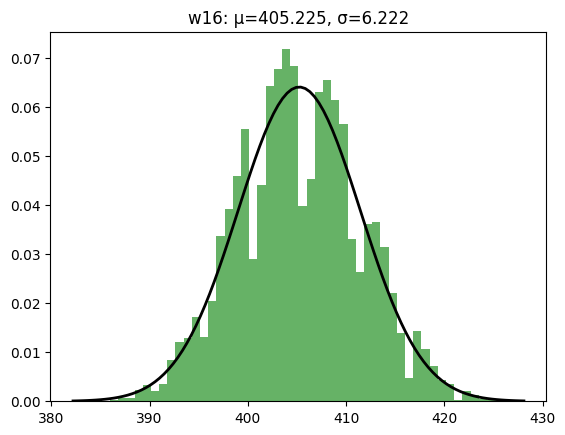

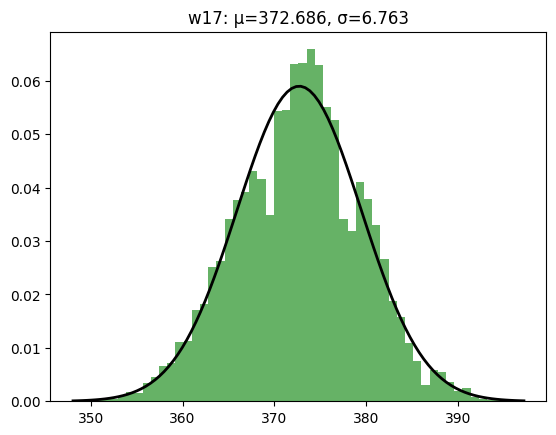

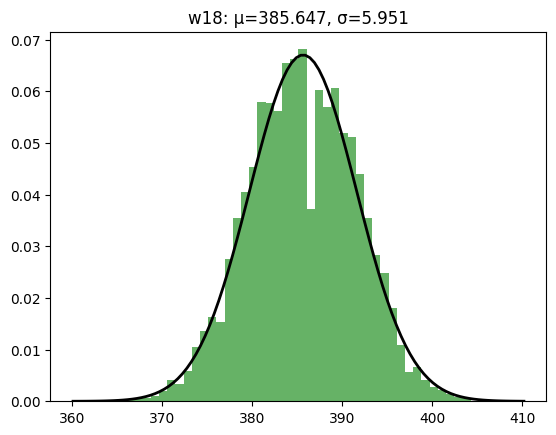

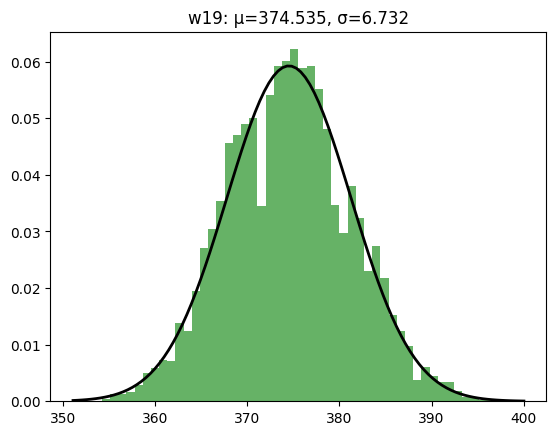

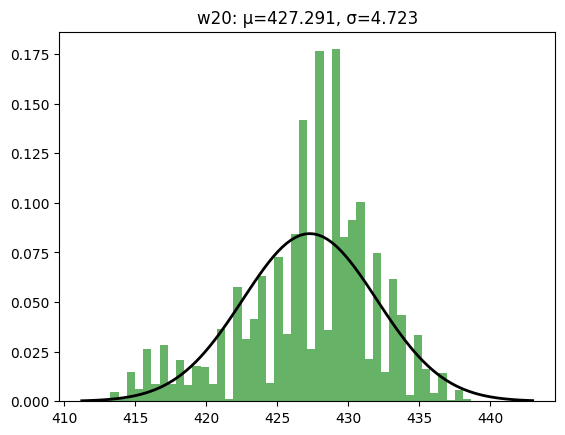

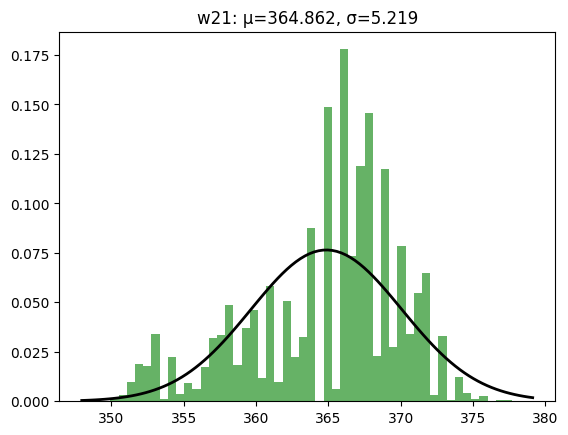

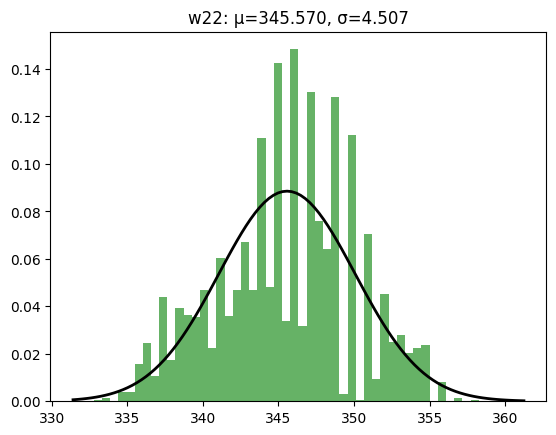

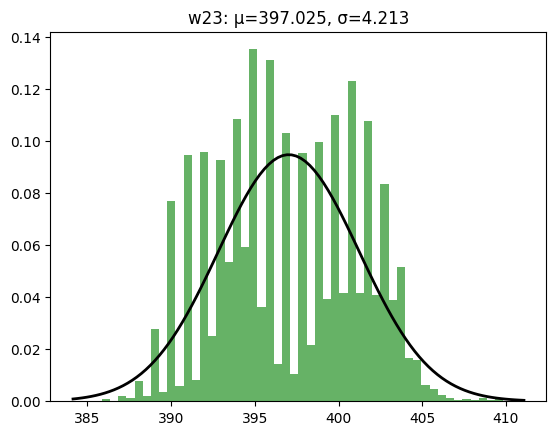

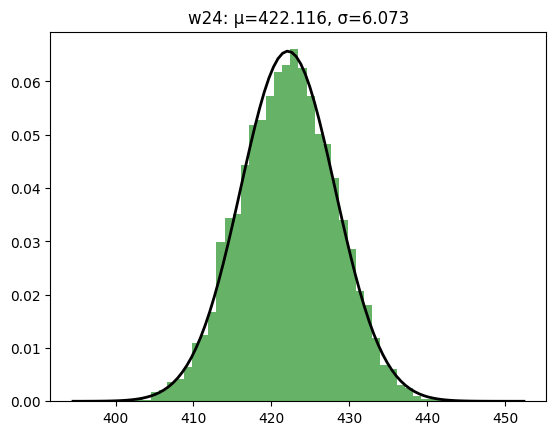

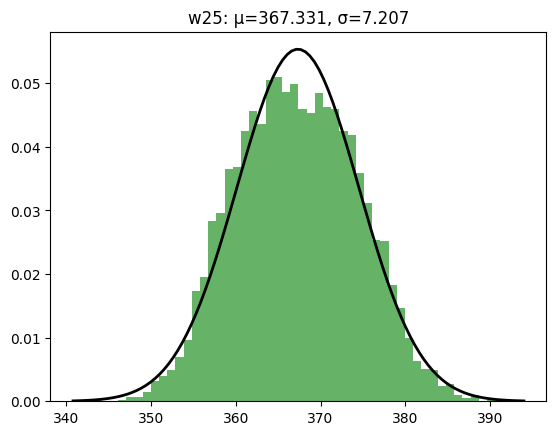

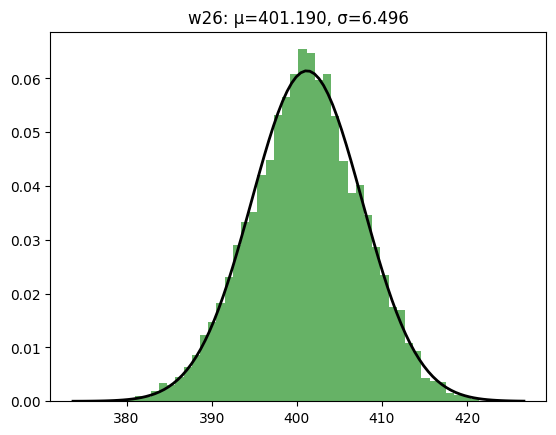

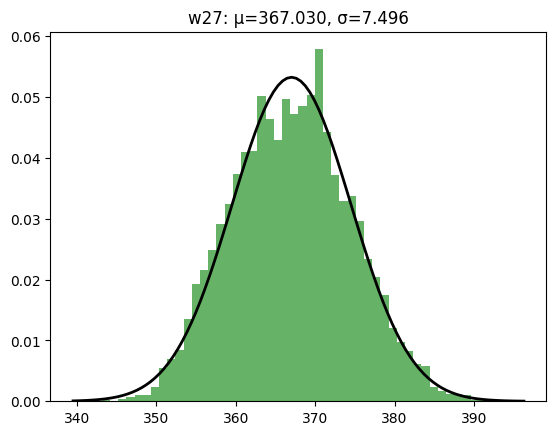

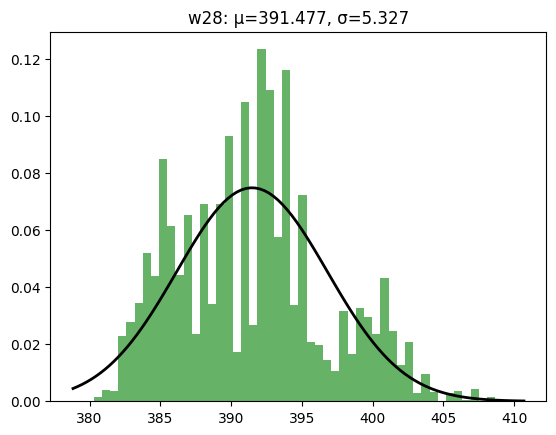

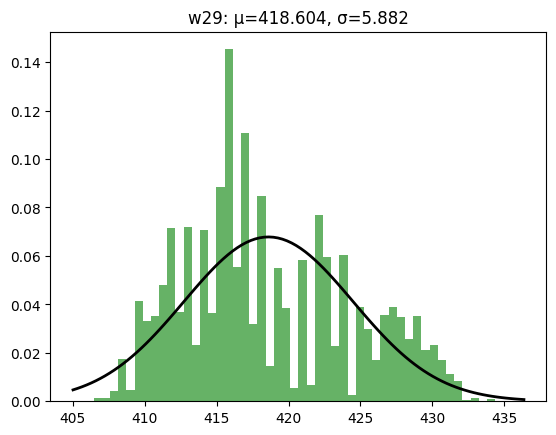

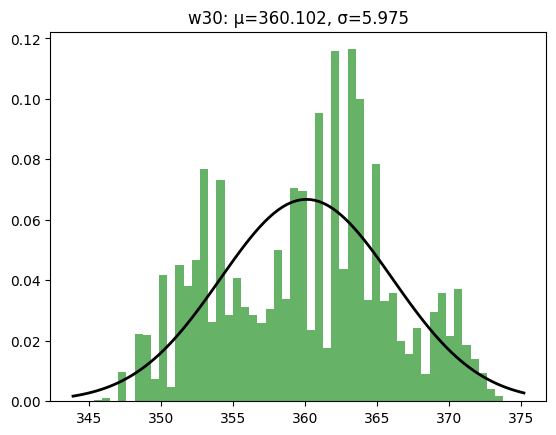

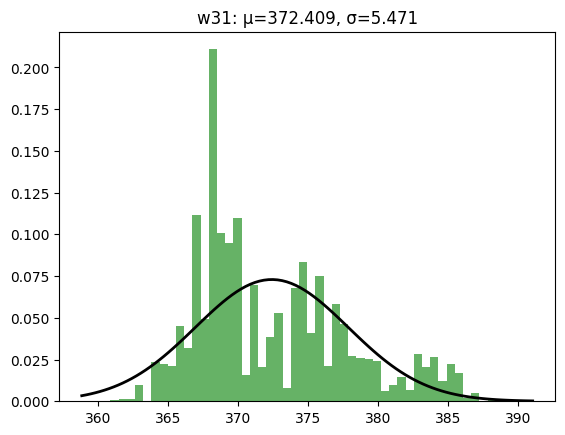

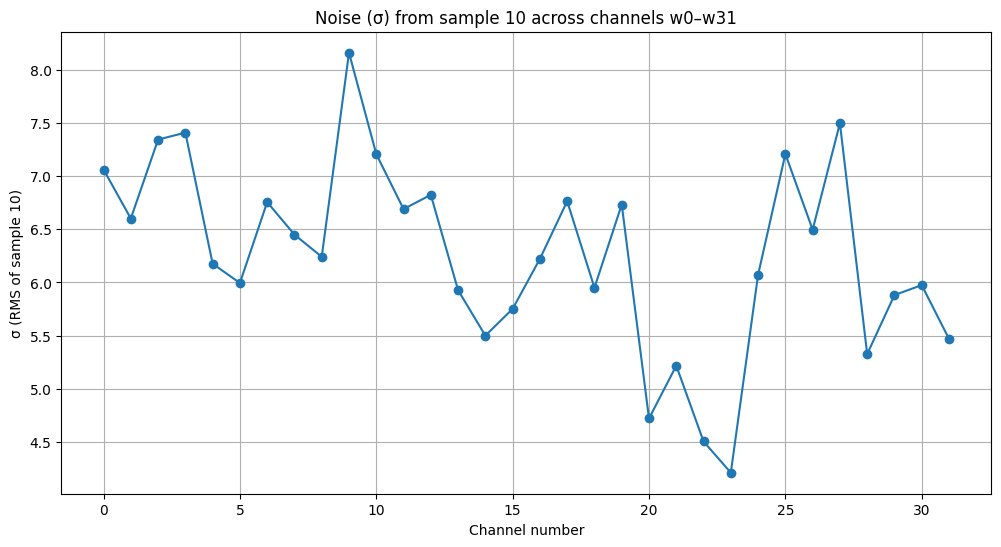

In [7]:
from scipy.stats import norm

# Number of channels (w0 ... w31)
wave_channels = [f"w{i}" for i in range(32)]

sigmas = []

for ch in wave_channels:
    # Get all waveforms for this channel
    data = tree[ch].array(library="np")

    # Extract value at sample 10 for each event
    sample_values = np.array([evt[10] for evt in data])

    # Fit to Gaussian
    mu, sigma = norm.fit(sample_values)
    sigmas.append(sigma)

    # (Optional) plot histogram + fit for each channel
    # Uncomment if you want to see the fits
    plt.hist(sample_values, bins=50, density=True, alpha=0.6, color='g')
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, sigma)
    plt.plot(x, p, 'k', linewidth=2)
    plt.title(f"{ch}: μ={mu:.3f}, σ={sigma:.3f}")
    plt.show()

# Now plot sigmas across channels
plt.figure(figsize=(12,6))
plt.plot(range(32), sigmas, marker="o")
plt.xlabel("Channel number")
plt.ylabel("σ (RMS of sample 10)")
plt.title("Noise (σ) from sample 10 across channels w0–w31")
plt.grid(True)
plt.show()

